In [1]:
!pip install osmnx

In [ ]:
import osmnx as ox

# Get graph from OSM XML (all data, then filter for walkable edges if needed)
G = ox.graph_from_xml("alex.osm", bidirectional=True, simplify=True)

# # Optionally, project to UTM for accurate distances
# G = ox.project_graph(G)


TypeError: graph_from_xml() got an unexpected keyword argument 'network_type'

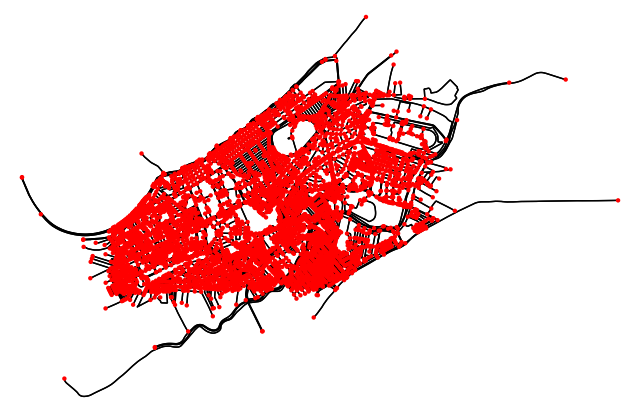

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
ox.plot_graph(G, node_size=10, node_color="red", edge_color="black", bgcolor="white")


In [3]:
import osmnx as ox
import folium

# Load graph from local OSM file (everything in it)
G = ox.graph_from_xml("alex.osm", simplify=True, bidirectional=True)

# Do NOT project if you want to display in Folium
# (Folium needs lat/lon coordinates, not meters)

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# # Center of map
# center = [nodes.geometry.y.mean(), nodes.geometry.x.mean()]
# m = folium.Map(location=center, zoom_start=14, tiles="cartodbpositron")

# # Add edges (in lat/lon)
# for _, row in edges.iterrows():
#     coords = [(y, x) for x, y in row.geometry.coords]
#     folium.PolyLine(coords, color="blue", weight=2, opacity=0.7).add_to(m)

# # Add nodes
# for _, row in nodes.iterrows():
#     folium.CircleMarker(location=(row.geometry.y, row.geometry.x),
#                         radius=2, color="red", fill=True).add_to(m)

# m


In [5]:
nodes['route'] = 'r1'
nodes

,y,x,highway,railway,geometry,route
osmid,,,,,,
-25481,31.219707,29.942645,NaN,NaN,POINT (29.94264 31.21971),r1
81312379,31.208773,29.912758,traffic_signals,NaN,POINT (29.91276 31.20877),r1
260754134,31.203910,29.885494,NaN,NaN,POINT (29.88549 31.20391),r1
260755101,31.201931,29.900353,NaN,NaN,POINT (29.90035 31.20193),r1
260755102,31.204785,29.904184,crossing,NaN,POINT (29.90418 31.20478),r1
...,...,...,...,...,...,...
13182147504,31.208279,29.906858,crossing,NaN,POINT (29.90686 31.20828),r1
13182147505,31.208217,29.906996,crossing,NaN,POINT (29.907 31.20822),r1
13182147506,31.208174,29.907092,NaN,NaN,POINT (29.90709 31.20817),r1


In [14]:
# select random node
nodes.sample()
# view neighboring nodes
ns = G.neighbors(nodes.sample().index[0])
list(ns)
# find the edges between the selected node and its neighbors
edges.loc[(edges.u == nodes.sample().index[0]) | (edges.v == nodes.sample().index[0])]

AttributeError: 'GeoDataFrame' object has no attribute 'u'

In [5]:
edges

osmid      highway  oneway  \
u            v           key                                                  
-25481       5862710097  0                   620539515      footway   False   
             5862710099  0                      -10323      footway   False   
             5862708183  0                   620539515      footway   False   
 81312379    7927869625  0                    25185997        trunk   False   
             7927869628  0                    25185997        trunk   False   
...                                                ...          ...     ...   
 13185421450 8178721516  0                   879153208      service   False   
             13185421451 0    [1434536440, 1434536438]      service   False   
 13185421451 1885696432  0                   178199821  residential   False   
             1885696359  0                   178199821  residential   False   
             13185421450 0    [1434536440, 1434536438]      service   False   

                             reversed     length  \
u            v           key                       
-25481       5862710097  0      False   7.149136   
             5862710099  0      False  28.864608   
             5862708183  0       True  24.373766   
 81312379    7927869625  0      False  11.667120   
             7927869628  0       True  12.074134   
...                               ...        ...   
 13185421450 8178721516  0      False  30.738696   
             13185421451 0       True  25.972942   
 13185421451 1885696432  0      False   3.630541   
             1885696359  0       True  51.165597   
             13185421450 0      False  25.972942   

                                                                       geometry  \
u            v           key                                                      
-25481       5862710097  0    LINESTRING (29.94264 31.21971, 29.94269 31.21966)   
             5862710099  0    LINESTRING (29.94264 31.21971, 29.94277 31.219...   
             5862708183  0    LINESTRING (29.94264 31.21971, 29.9425 31.2198...   
 81312379    7927869625  0     LINESTRING (29.91276 31.20877, 29.9128 31.20868)   
             7927869628  0    LINESTRING (29.91276 31.20877, 29.91271 31.20888)   
...                                                                         ...   
 13185421450 8178721516  0    LINESTRING (29.90029 31.19927, 29.90024 31.199...   
             13185421451 0    LINESTRING (29.90029 31.19927, 29.90019 31.199...   
 13185421451 1885696432  0    LINESTRING (29.90015 31.19947, 29.90018 31.19949)   
             1885696359  0    LINESTRING (29.90015 31.19947, 29.9 31.1994, 2...   
             13185421450 0    LINESTRING (29.90015 31.19947, 29.90019 31.199...   

                                                name maxspeed lanes  ref  \
u            v           key                                               
-25481       5862710097  0                       NaN      NaN   NaN  NaN   
             5862710099  0                       NaN      NaN   NaN  NaN   
             5862708183  0                       NaN      NaN   NaN  NaN   
 81312379    7927869625  0          طريق قناه السويس      NaN   NaN  NaN   
             7927869628  0          طريق قناه السويس      NaN   NaN  NaN   
...                                              ...      ...   ...  ...   
 13185421450 8178721516  0                       NaN      NaN   NaN  NaN   
             13185421451 0                       NaN      NaN   NaN  NaN   
 13185421451 1885696432  0    شارع الدكتور حسن فضالي      NaN   NaN  NaN   
             1885696359  0    شارع الدكتور حسن فضالي      NaN   NaN  NaN   
             13185421450 0                       NaN      NaN   NaN  NaN   

                             junction tunnel   access bridge service area  
u            v           key                                               
-25481       5862710097  0        NaN    NaN      NaN    NaN     NaN  NaN  
             5862710099  0        NaN    NaN   

In [38]:
import heapq
import osmnx as ox

def explore_routes(G, source, cutoff=float("inf")):
    # Dijkstra-like expansion
    dist = {source: 0}
    prev = {}
    pq = [(0, source)]
    visited = set()

    # results: route_name -> (distance, end_node, path)
    routes = {}

    def reconstruct_path(node):
        path = []
        while node in prev:
            path.append(node)
            node = prev[node]
        path.append(source)
        return list(reversed(path))

    while pq:
        d, node = heapq.heappop(pq)
        if d > cutoff:   # stop at cutoff
            break
        if node in visited:
            continue
        visited.add(node)

        # if this node has a route attribute
        route_name = G.nodes[node].get("route")
        if route_name:
            # if it's the first time OR shorter distance found
            if route_name not in routes or d < routes[route_name][0]:
                routes[route_name] = (d, node, reconstruct_path(node))

        # relax neighbors
        for nbr, edge_data in G[node].items():
            for key, attr in edge_data.items():
                length = attr.get("length", 1)
                nd = d + length
                if nd < dist.get(nbr, float("inf")) and nd <= cutoff:
                    dist[nbr] = nd
                    prev[nbr] = node
                    heapq.heappush(pq, (nd, nbr))

    return routes


In [3]:
import osmnx as ox

# Load walking network
G = ox.graph_from_xml("alex.osm", simplify=True, bidirectional=True)

lon, lat = 29.96139328537071, 31.22968895248673
# Pick a source node
source = ox.distance.nearest_nodes(G, X=lon, Y=lat)

# Run exploration up to 5 km
routes = explore_routes(G, source, cutoff=5000)

# Print results
print("Reachable routes:", list(routes.keys()))
for r, (dist, node, path) in routes.items():
    print(f"{r} -> node {node} at {dist:.1f} meters, path length {len(path)}")


Reachable routes: []


In [2]:
import osmnx as ox
G = ox.graph_from_xml("alex.osm", simplify=True, bidirectional=True)
# save the graph to a file
ox.save_graphml(G, "alex.graphml")

In [15]:
print("Loading labeled graph from 'alex_labeled.osm'...")
# Load the graph directly from your JOSM-edited file
G_labeled = ox.graph_from_xml("labeled.osm", simplify=True)

# Now you can use this labeled graph as before
lon, lat = 29.96139328537071, 31.22968895248673
source_node = ox.distance.nearest_nodes(G_labeled, X=lon, Y=lat)

print(f"Starting route exploration from node {source_node}...")
# Run exploration up to 5 km (5000 meters)
routes = explore_routes(G_labeled, source_node, cutoff=5000)

# Print the results
print("\n--- Results ---")
print("Reachable routes within 5km:", list(routes.keys()))
for r, (dist, node, path) in routes.items():
    print(f"- Route '{r}' found at node {node} ({dist:.1f} meters away)")

Loading labeled graph from 'alex_labeled.osm'...
Starting route exploration from node 4166047227...

--- Results ---
Reachable routes within 5km: []


In [43]:
import folium
import itertools
def plot_routes_on_map(G_labeled, source_node, explored_path_list):
    # Get the starting node's coordinates
    start_lat = G_labeled.nodes[source_node]['y']
    start_lon = G_labeled.nodes[source_node]['x']
    # Create a folium map centered at the starting node
    # m = folium.Map(location=[start_lat, start_lon], zoom_start=14, tiles="cartodbpositron")
    m = folium.Map(location=[start_lat, start_lon], zoom_start=15, tiles="cartodbpositron")
    # --- Draw explored paths (blue) ---
    for path in itertools.islice(explored_path_list, 0, 2000):  # Limit to first 200 for speed
        folium.PolyLine(
            [(G_labeled.nodes[n]['y'], G_labeled.nodes[n]['x']) for n in path],
            color='blue', weight=2, opacity=0.4
        ).add_to(m)
    # --- Draw source node (red) ---
    folium.CircleMarker(
        location=(start_lat, start_lon),
        radius=5, color='red', fill=True
    ).add_to(m)
    return m
# Now you can use this labeled graph as before
lon, lat = 29.96139328537071, 31.22968895248673
source_node = ox.distance.nearest_nodes(G_labeled, X=lon, Y=lat)
print(source_node)

print(f"Starting route exploration from node {source_node}...")
# Run exploration up to 5 km (5000 meters)
routes = explore_routes(G_labeled, source_node, cutoff=2000)

# Print the results
print("\n--- Results ---")
print("Reachable routes within 5km:", list(routes.keys()))
for r, (dist, node, path) in routes.items():
    print(f"- Route '{r}' found at node {node} ({dist:.1f} meters away)")
    # display this r path 
    # display the path on a folium map
    m = plot_routes_on_map(G_labeled, source_node, [path])
    m.save(f"route_{r}.html")

4166047227
Starting route exploration from node 4166047227...

--- Results ---
Reachable routes within 5km: ['r4', 'r3']
- Route 'r4' found at node 4166054905 (564.2 meters away)
- Route 'r3' found at node 5064688375 (628.8 meters away)


{'r4': (564.2384638376788,
  4166054905,
  [4166047227,
   1886562849,
   6977064720,
   6977064719,
   4166054337,
   1886562895,
   6986740396,
   6977079022,
   4166048754,
   1886562842,
   4166054445,
   6346410640,
   1886591034,
   4166054905]),
 'r3': (628.8344887048064,
  5064688375,
  [4166047227,
   1886562849,
   6987704454,
   6977064774,
   5493600606,
   528611580,
   6411025349,
   6977079040,
   8475961780,
   528611014,
   339078211,
   4709690776,
   5064688375])}

In [32]:
import xml.etree.ElementTree as ET

def inject_route_tags(G, osm_file):
    tree = ET.parse(osm_file)
    root = tree.getroot()
    count = 0

    for node in root.findall("node"):
        node_id = int(node.attrib["id"])
        for tag in node.findall("tag"):
            if tag.attrib.get("k") == "route":
                route_value = tag.attrib.get("v")
                if node_id in G.nodes:
                    G.nodes[node_id]["route"] = route_value
                    count += 1
    print(f"✅ Injected 'route' tags into {count} nodes.")


In [33]:
inject_route_tags(G_labeled, "labeled.osm")

✅ Injected 'route' tags into 9 nodes.


In [34]:
G_labeled.nodes[5064688373]

{'y': 31.231641, 'x': 29.9562903, 'route': 'r3'}